In [1]:
import numpy, sklearn, xgboost, joblib
print("numpy  :", numpy.__version__)   
print("sklearn:", sklearn.__version__) 
print("xgboost:", xgboost.__version__) 
print("joblib :", joblib.__version__)  
print("\nAll good — kernel matches training environment")

numpy  : 1.24.4
sklearn: 1.6.1
xgboost: 2.1.4
joblib : 1.5.2

All good — kernel matches training environment


In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    recall_score, precision_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

ORGANISM = 'ecoli'
BASE_DIR = r'C:\AMR_Prediction_Project'
DATA_DIR = os.path.join(BASE_DIR, 'Data', f'results_{ORGANISM}')

COLORS = {'LR':'#1D9E75', 'RF':'#534AB7', 'XGB':'#D85A30'}
OVERFIT_THRESHOLD = 0.08

plt.rcParams.update({
    'figure.dpi':130, 'axes.spines.top':False,
    'axes.spines.right':False, 'axes.grid':True,
    'grid.alpha':0.3, 'axes.titlesize':13,
    'axes.labelsize':11, 'xtick.labelsize':10,
    'ytick.labelsize':10,
})
print("Imports done")

Imports done


In [4]:
# Load best params
with open(os.path.join(DATA_DIR, 'best_params.json')) as f:
    params = json.load(f)
print("Params:", json.dumps(params, indent=2))

Params: {
  "LR": {
    "C": 0.1,
    "penalty": "l2",
    "solver": "liblinear"
  },
  "RF": {
    "max_depth": 5,
    "max_features": 0.3,
    "min_samples_leaf": 15,
    "n_estimators": 300
  },
  "XGB": {
    "colsample_bytree": 0.4,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_child_weight": 15,
    "n_estimators": 200,
    "reg_alpha": 1.0,
    "reg_lambda": 10,
    "subsample": 0.6
  }
}


In [5]:
# Load model-specific feature sets
def load_split(suffix):
    tr = pd.read_csv(os.path.join(DATA_DIR, f'train_selected_{suffix}.csv'))
    te = pd.read_csv(os.path.join(DATA_DIR, f'test_selected_{suffix}.csv'))
    Xtr = tr.drop(columns=['label','genome'], errors='ignore')
    ytr = tr['label']
    Xte = te.drop(columns=['label','genome'], errors='ignore')
    yte = te['label']
    return Xtr, ytr, Xte, yte

Xtr_lr,  ytr_lr,  Xte_lr,  yte_lr  = load_split('LR')
Xtr_rf,  ytr_rf,  Xte_rf,  yte_rf  = load_split('RF')
Xtr_xgb, ytr_xgb, Xte_xgb, yte_xgb = load_split('XGB')

print(f"LR  features: {Xtr_lr.shape[1]}")
print(f"RF  features: {Xtr_rf.shape[1]}")
print(f"XGB features: {Xtr_xgb.shape[1]}")

LR  features: 80
RF  features: 40
XGB features: 30


In [6]:
# Retrain all three models using best params
# (takes 1-2 minutes)
lrp  = params['LR']
rfp  = params['RF']
xgbp = params['XGB']

scaler   = StandardScaler()
Xtr_lr_sc = scaler.fit_transform(Xtr_lr)
Xte_lr_sc = scaler.transform(Xte_lr)

print("Training Logistic Regression...")
lr = LogisticRegression(
    C=lrp['C'], penalty=lrp['penalty'],
    solver=lrp.get('solver','liblinear'),
    max_iter=2000, class_weight='balanced', n_jobs=-1
)
lr.fit(Xtr_lr_sc, ytr_lr)

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=rfp.get('n_estimators', 200),
    max_depth=min(rfp['max_depth'], 5),
    min_samples_leaf=max(rfp['min_samples_leaf'], 15),
    max_features=rfp.get('max_features', 0.2),
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf.fit(Xtr_rf, ytr_rf)

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=xgbp.get('n_estimators', 200),
    max_depth=min(xgbp['max_depth'], 3),
    learning_rate=xgbp.get('learning_rate', 0.01),
    subsample=xgbp.get('subsample', 0.5),
    colsample_bytree=xgbp.get('colsample_bytree', 0.5),
    reg_lambda=max(xgbp.get('reg_lambda', 20), 10),
    reg_alpha=max(xgbp.get('reg_alpha', 1.0), 1.0),
    min_child_weight=max(xgbp.get('min_child_weight', 15), 15),
    eval_metric='logloss', random_state=42,
    use_label_encoder=False
)
xgb.fit(Xtr_xgb, ytr_xgb)
print("All models trained!")


Training Logistic Regression...
Training Random Forest...
Training XGBoost...
All models trained!


In [7]:
with open(os.path.join(DATA_DIR, 'thresholds.json')) as f:
    thresholds = json.load(f)



print("Final thresholds being used:")
for k, t in thresholds.items():
    print(f"  {k}: {t}")

Final thresholds being used:
  LR: 0.45
  RF: 0.47
  XGB: 0.48


In [8]:
MODELS = {
    'LR' : dict(model=lr,  Xtr=Xtr_lr_sc, ytr=ytr_lr,
                Xte=Xte_lr_sc, yte=yte_lr,  feats=Xtr_lr.shape[1]),
    'RF' : dict(model=rf,  Xtr=Xtr_rf,    ytr=ytr_rf,
                Xte=Xte_rf,    yte=yte_rf,  feats=Xtr_rf.shape[1]),
    'XGB': dict(model=xgb, Xtr=Xtr_xgb,   ytr=ytr_xgb,
                Xte=Xte_xgb,   yte=yte_xgb, feats=Xtr_xgb.shape[1]),
}

for k, m in MODELS.items():
    t = thresholds[k]
    m['tr_prob'] = m['model'].predict_proba(m['Xtr'])[:, 1]
    m['te_prob'] = m['model'].predict_proba(m['Xte'])[:, 1]
    m['te_pred'] = (m['te_prob'] >= t).astype(int)
    m['tr_pred'] = (m['tr_prob'] >= t).astype(int)
    m['threshold'] = t
    auc = roc_auc_score(m['yte'], m['te_prob'])
    print(f"{k}: threshold={t}  test AUC={auc:.4f}  features={m['feats']}")

LR: threshold=0.45  test AUC=0.8734  features=80
RF: threshold=0.47  test AUC=0.8597  features=40
XGB: threshold=0.48  test AUC=0.8753  features=30


In [9]:
rows = []
for k, m in MODELS.items():
    yte, ytr = m['yte'], m['ytr']
    te_prob, tr_prob = m['te_prob'], m['tr_prob']
    te_pred, tr_pred = m['te_pred'], m['tr_pred']
    t = m['threshold']

    test_auc  = roc_auc_score(yte, te_prob)
    train_auc = roc_auc_score(ytr, tr_prob)
    gap       = train_auc - test_auc
    cm        = confusion_matrix(yte, te_pred)
    tn,fp,fn,tp = cm.ravel()

    rows.append({
        'Model'              : k,
        'Features'           : m['feats'],
        'Threshold'          : t,
        'Train AUC'          : round(train_auc, 4),
        'Test AUC'           : round(test_auc,  4),
        'AUC Gap'            : round(gap,        4),
        'PR-AUC'             : round(average_precision_score(yte, te_prob), 4),
        'F1'                 : round(f1_score(yte, te_pred),                4),
        'MCC'                : round(matthews_corrcoef(yte, te_pred),       4),
        'Accuracy'           : round(accuracy_score(yte, te_pred),          4),
        'Res. Recall'        : round(recall_score(yte, te_pred),            4),
        'Res. Precision'     : round(precision_score(yte, te_pred),         4),
        'FN (missed resist.)': int(fn),
        'TN': int(tn), 'FP': int(fp), 'TP': int(tp),
    })

summary = pd.DataFrame(rows).set_index('Model')

# Highlight best value per metric
def highlight(s):
    best = s.max() if s.name not in ['AUC Gap','FN (missed resist.)','FP'] else s.min()
    return ['background-color:#d4edda; font-weight:bold' if v == best else '' for v in s]

display_cols = ['Features','Threshold','Train AUC','Test AUC','AUC Gap',
                'PR-AUC','F1','MCC','Accuracy','Res. Recall','Res. Precision','FN (missed resist.)']

summary[display_cols].style\
    .apply(highlight, subset=['Test AUC','PR-AUC','F1','MCC','Accuracy',
                               'Res. Recall','Res. Precision'])\
    .apply(highlight, subset=['AUC Gap','FN (missed resist.)'])\
    .format(precision=4)\
    .set_caption('E. coli AMR — Final results summary (tuned thresholds)')

,Features,Threshold,Train AUC,Test AUC,AUC Gap,PR-AUC,F1,MCC,Accuracy,Res. Recall,Res. Precision,FN (missed resist.)
Model,,,,,,,,,,,,
LR,80,0.4500,0.9249,0.8734,0.0515,0.8638,0.7954,0.5972,0.7985,0.7833,0.8078,57
RF,40,0.4700,0.9411,0.8597,0.0814,0.8699,0.7665,0.5577,0.7776,0.7300,0.8067,71
XGB,30,0.4800,0.9447,0.8753,0.0694,0.8866,0.7737,0.5555,0.7776,0.7605,0.7874,63


In [10]:
# Build updated results dataframe from current MODELS dict
# and save to final_results.csv — overwrites old file

rows = []
for k, m in MODELS.items():
    yte = m['yte']
    ytr = m['ytr']
    te_prob = m['te_prob']
    tr_prob = m['tr_prob']
    te_pred = m['te_pred']
    tr_pred = m['tr_pred']
    t       = m['threshold']

    cm = confusion_matrix(yte, te_pred)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        'Model'              : k,
        'Features'           : m['feats'],
        'Threshold'          : t,
        'Train AUC'          : round(roc_auc_score(ytr, tr_prob), 4),
        'Test AUC'           : round(roc_auc_score(yte, te_prob), 4),
        'AUC Gap'            : round(roc_auc_score(ytr, tr_prob) -
                                     roc_auc_score(yte, te_prob), 4),
        'PR-AUC'             : round(average_precision_score(yte, te_prob), 4),
        'F1'                 : round(f1_score(yte, te_pred), 4),
        'MCC'                : round(matthews_corrcoef(yte, te_pred), 4),
        'Accuracy'           : round(accuracy_score(yte, te_pred), 4),
        'Res. Recall'        : round(recall_score(yte, te_pred), 4),
        'Res. Precision'     : round(precision_score(yte, te_pred), 4),
        'TN'                 : int(tn),
        'FP'                 : int(fp),
        'FN (missed resist.)': int(fn),
        'TP'                 : int(tp),
    })

results_df = pd.DataFrame(rows)

# Save — overwrites old file
out_path = os.path.join(DATA_DIR, 'final_results.csv')
results_df.to_csv(out_path, index=False)

print("Updated final_results.csv saved successfully")
print(f"Location: {out_path}")
print()
print(results_df[['Model','Features','Threshold','Test AUC',
                   'AUC Gap','MCC','FN (missed resist.)']].to_string(index=False))

Updated final_results.csv saved successfully
Location: C:\AMR_Prediction_Project\Data\results_ecoli\final_results.csv

Model  Features  Threshold  Test AUC  AUC Gap    MCC  FN (missed resist.)
   LR        80       0.45    0.8734   0.0515 0.5972                   57
   RF        40       0.47    0.8597   0.0814 0.5577                   71
  XGB        30       0.48    0.8753   0.0694 0.5555                   63


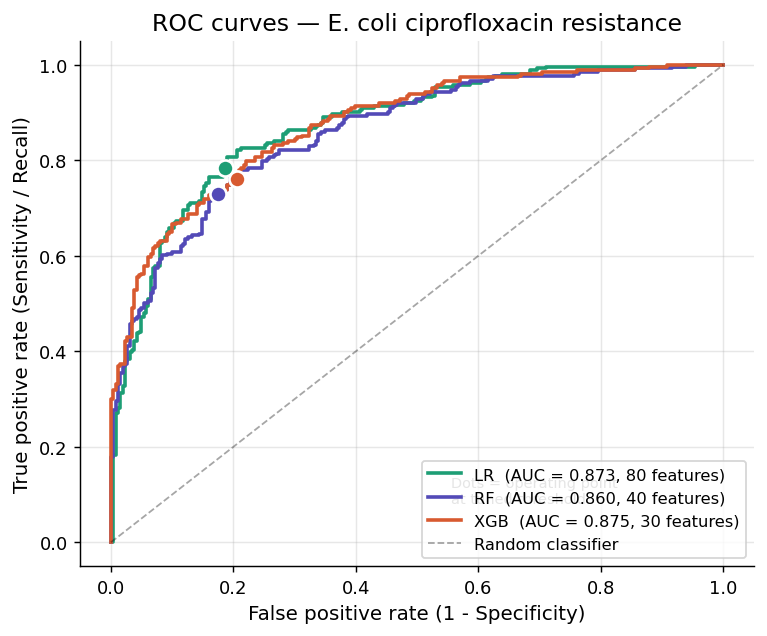

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

for k, m in MODELS.items():
    fpr, tpr, _ = roc_curve(m['yte'], m['te_prob'])
    auc = roc_auc_score(m['yte'], m['te_prob'])
    ax.plot(fpr, tpr, color=COLORS[k], lw=2,
            label=f'{k}  (AUC = {auc:.3f}, {m["feats"]} features)')
    # Mark the operating threshold point
    t = m['threshold']
    te_pred_pts = (m['te_prob'] >= t).astype(int)
    op_tpr = recall_score(m['yte'], te_pred_pts)
    op_fpr = 1 - recall_score(1 - m['yte'], 1 - te_pred_pts)
    ax.scatter(op_fpr, op_tpr, color=COLORS[k], s=80, zorder=5,
               edgecolors='white', linewidths=1.5)

ax.plot([0,1],[0,1],'k--', alpha=0.35, lw=1, label='Random classifier')
ax.set_xlabel('False positive rate (1 - Specificity)')
ax.set_ylabel('True positive rate (Sensitivity / Recall)')
ax.set_title('ROC curves — E. coli ciprofloxacin resistance')
ax.legend(fontsize=9, loc='lower right')
ax.text(0.55, 0.12, 'Dots = operating point\nat tuned threshold',
        fontsize=8, color='gray', transform=ax.transAxes)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

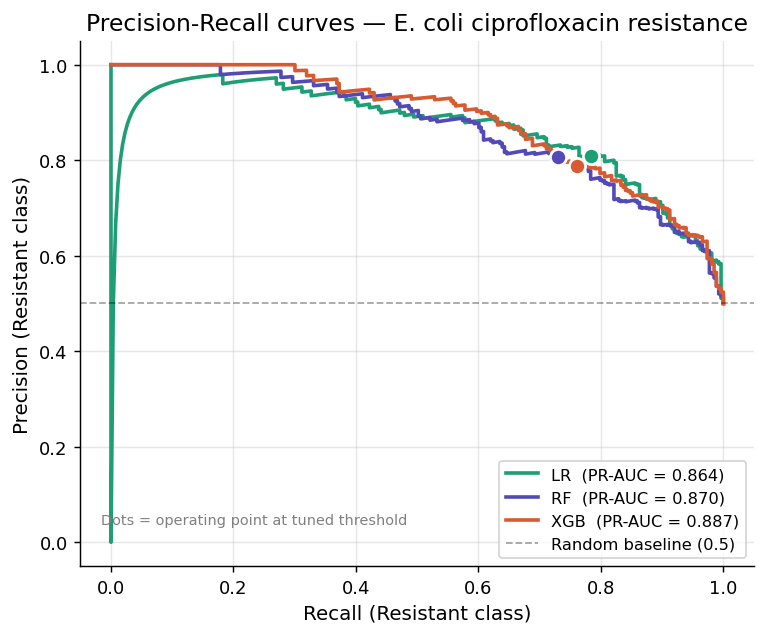

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

for k, m in MODELS.items():
    prec, rec, _ = precision_recall_curve(m['yte'], m['te_prob'])
    ap = average_precision_score(m['yte'], m['te_prob'])
    ax.plot(rec, prec, color=COLORS[k], lw=2,
            label=f'{k}  (PR-AUC = {ap:.3f})')
    # Operating point
    op_rec  = recall_score(m['yte'], m['te_pred'])
    op_prec = precision_score(m['yte'], m['te_pred'])
    ax.scatter(op_rec, op_prec, color=COLORS[k], s=80, zorder=5,
               edgecolors='white', linewidths=1.5)

# Baseline = class prevalence (0.5 balanced)
ax.axhline(0.5, color='k', linestyle='--', alpha=0.35, lw=1, label='Random baseline (0.5)')
ax.set_xlabel('Recall (Resistant class)')
ax.set_ylabel('Precision (Resistant class)')
ax.set_title('Precision-Recall curves — E. coli ciprofloxacin resistance')
ax.legend(fontsize=9)
ax.text(0.03, 0.08, 'Dots = operating point at tuned threshold',
        fontsize=8, color='gray', transform=ax.transAxes)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

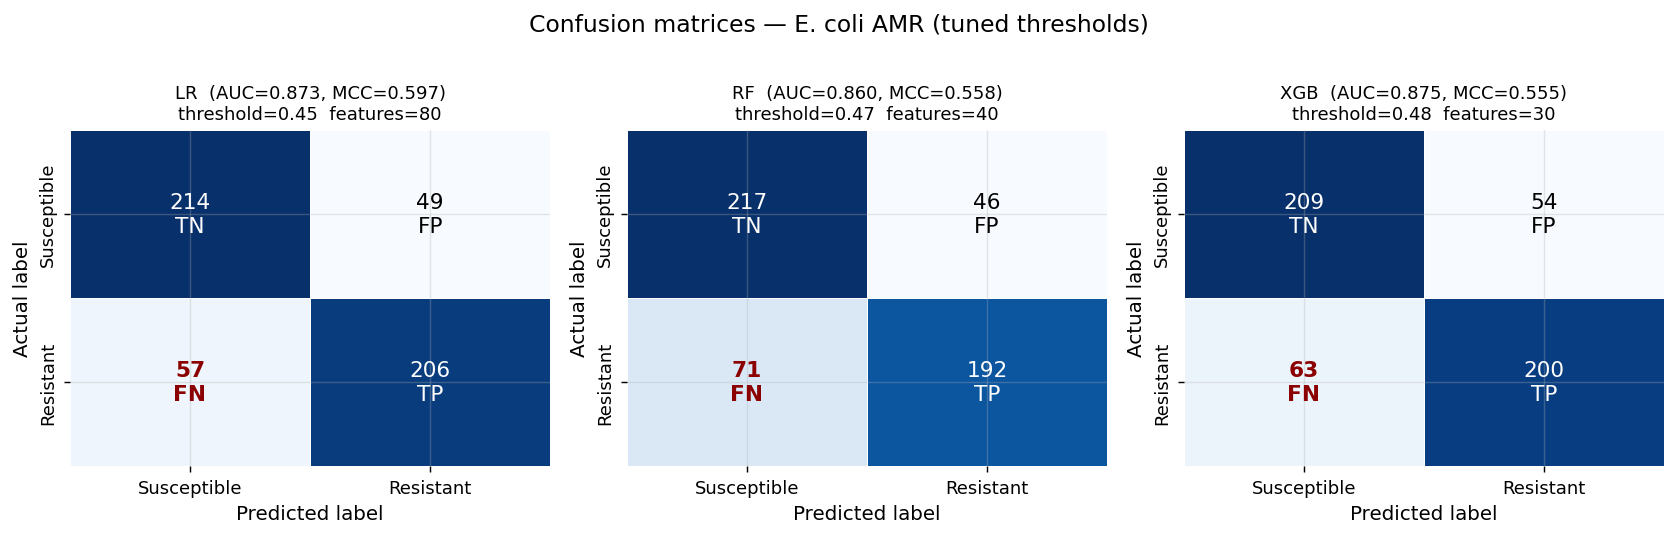

FN = missed resistant genomes (dark red) — the most clinically critical error


In [13]:
CLASS_NAMES = ['Susceptible', 'Resistant']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (k, m) in zip(axes, MODELS.items()):
    cm = confusion_matrix(m['yte'], m['te_pred'])
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='white',
                cbar=False, ax=ax)

    thresh_color = cm.max() / 2
    labels = {(0,0): f'{tn}\nTN', (0,1): f'{fp}\nFP',
              (1,0): f'{fn}\nFN', (1,1): f'{tp}\nTP'}
    weights = {(0,0):'normal',(0,1):'normal',(1,0):'bold',(1,1):'normal'}
    colors_fn = {(0,0):'white',(0,1):'black',(1,0):'black',(1,1):'white'}

    for (i, j), val in np.ndenumerate(cm):
        color = 'white' if val > thresh_color else 'black'
        if (i,j) == (1,0): color = '#8B0000'
        ax.text(j + 0.5, i + 0.5, labels[(i,j)],
                ha='center', va='center', fontsize=12,
                fontweight=weights[(i,j)], color=color)

    auc  = roc_auc_score(m['yte'], m['te_prob'])
    mcc  = matthews_corrcoef(m['yte'], m['te_pred'])
    ax.set_title(f'{k}  (AUC={auc:.3f}, MCC={mcc:.3f})\nthreshold={m["threshold"]}  features={m["feats"]}',
                 fontsize=10)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Actual label')

fig.suptitle('Confusion matrices — E. coli AMR (tuned thresholds)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('FN = missed resistant genomes (dark red) — the most clinically critical error')

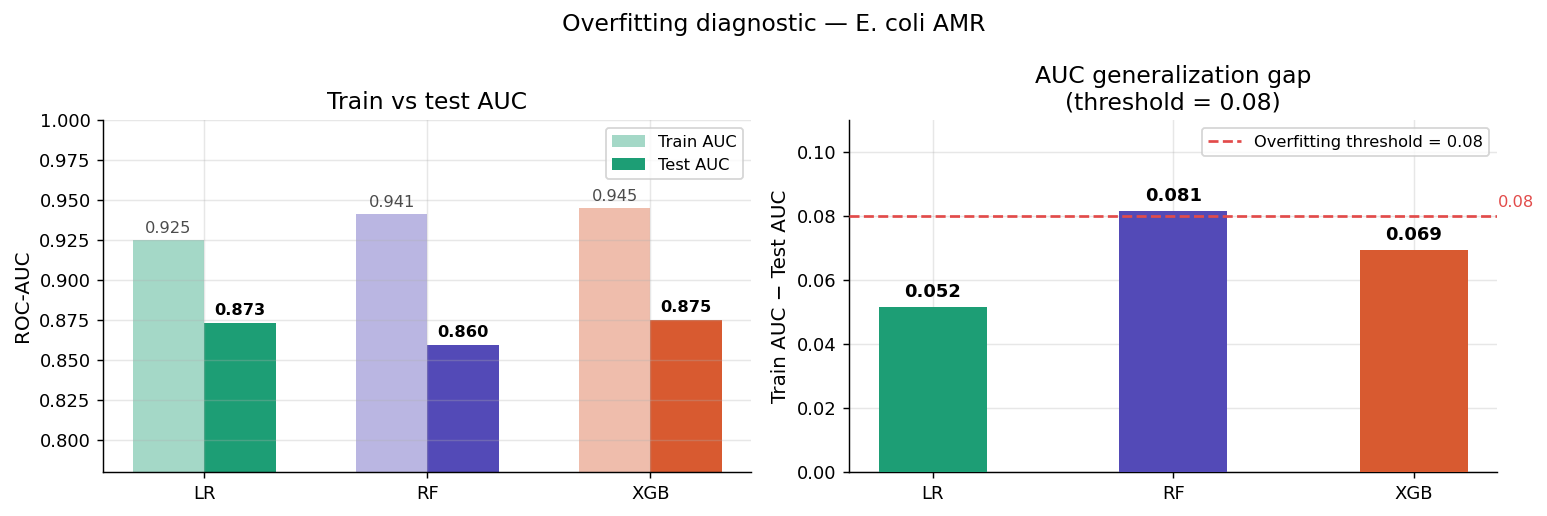

Threshold set to 0.08. 


In [23]:
model_names = list(MODELS.keys())
train_aucs  = [roc_auc_score(m['ytr'], m['tr_prob']) for m in MODELS.values()]
test_aucs   = [roc_auc_score(m['yte'], m['te_prob']) for m in MODELS.values()]
gaps        = [tr - te for tr, te in zip(train_aucs, test_aucs)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: grouped bar ────────────────────────────────────────────
ax = axes[0]
x  = np.arange(len(model_names))
w  = 0.32
b1 = ax.bar(x - w/2, train_aucs, w, label='Train AUC',
            color=[COLORS[k] for k in model_names], alpha=0.4)
b2 = ax.bar(x + w/2, test_aucs,  w, label='Test AUC',
            color=[COLORS[k] for k in model_names], alpha=1.0)

for bar, val in zip(b1, train_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, alpha=0.7)
for bar, val in zip(b2, test_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0.78, 1.00)
ax.set_ylabel('ROC-AUC')
ax.set_title('Train vs test AUC')
ax.legend(fontsize=9)

# ── Right: AUC gap bar with single threshold ──────────────────────
ax2 = axes[1]
gap_colors = [COLORS[k] for k in model_names]
bars = ax2.bar(model_names, gaps, color=gap_colors, width=0.45, zorder=3)

# Single threshold line
ax2.axhline(OVERFIT_THRESHOLD, color='#E24B4A', linestyle='--',
            lw=1.5, zorder=4,
            label=f'Overfitting threshold = {OVERFIT_THRESHOLD}')
ax2.text(2.35, OVERFIT_THRESHOLD + 0.002,
         f'{OVERFIT_THRESHOLD}', color='#E24B4A', fontsize=9, va='bottom')

for bar, gap in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, gap + 0.002,
             f'{gap:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Train AUC − Test AUC')
ax2.set_title(f'AUC generalization gap\n(threshold = {OVERFIT_THRESHOLD})')
ax2.set_ylim(0, max(gaps) * 1.35)
ax2.legend(fontsize=9)

plt.suptitle('Overfitting diagnostic — E. coli AMR', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'overfitting_diagnostic.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Threshold set to {OVERFIT_THRESHOLD}. ')

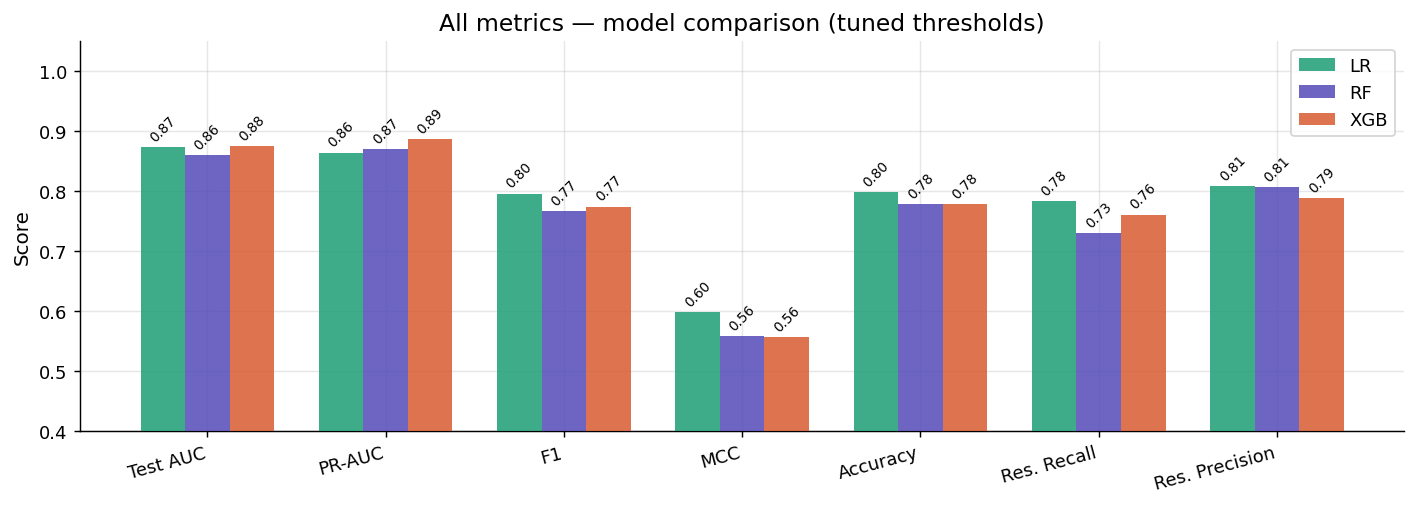

In [15]:
metrics = ['Test AUC', 'PR-AUC', 'F1', 'MCC', 'Accuracy', 'Res. Recall', 'Res. Precision']
fig, ax = plt.subplots(figsize=(11, 4))

x   = np.arange(len(metrics))
w   = 0.25
off = [-w, 0, w]

for i, (k, m) in enumerate(MODELS.items()):
    vals = [summary.loc[k, met] for met in metrics]
    bars = ax.bar(x + off[i], vals, w, label=k,
                  color=COLORS[k], alpha=0.85, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=7.5, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Score')
ax.set_title('All metrics — model comparison (tuned thresholds)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'metric_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

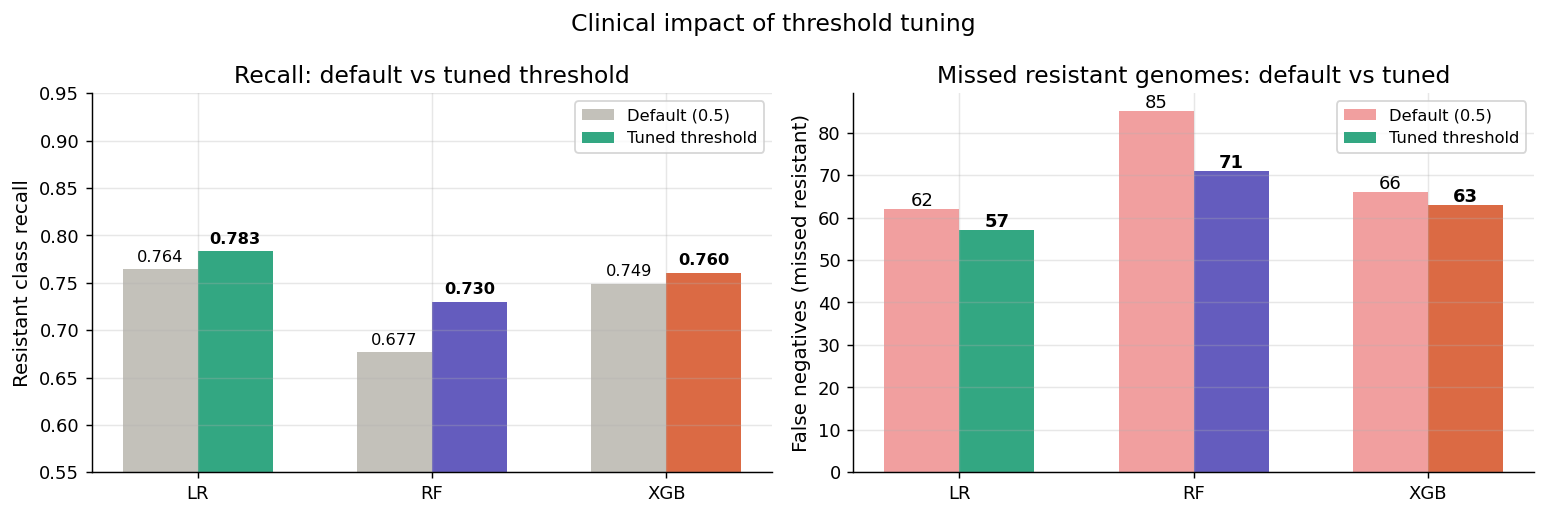

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

recall_def, recall_tun, fn_def, fn_tun, prec_def, prec_tun = [], [], [], [], [], []

for k, m in MODELS.items():
    pred_def = (m['te_prob'] >= 0.5).astype(int)
    pred_tun = m['te_pred']
    recall_def.append(recall_score(m['yte'], pred_def))
    recall_tun.append(recall_score(m['yte'], pred_tun))
    prec_def.append(precision_score(m['yte'], pred_def))
    prec_tun.append(precision_score(m['yte'], pred_tun))
    cm_def = confusion_matrix(m['yte'], pred_def)
    cm_tun = confusion_matrix(m['yte'], pred_tun)
    fn_def.append(cm_def.ravel()[2])
    fn_tun.append(cm_tun.ravel()[2])

x  = np.arange(len(model_names))
w  = 0.32

# Recall comparison
ax = axes[0]
ax.bar(x - w/2, recall_def, w, label='Default (0.5)', color='#B4B2A9', alpha=0.8)
ax.bar(x + w/2, recall_tun, w, label='Tuned threshold',
       color=[COLORS[k] for k in model_names], alpha=0.9)
for i, (rd, rt) in enumerate(zip(recall_def, recall_tun)):
    ax.text(i - w/2, rd + 0.008, f'{rd:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, rt + 0.008, f'{rt:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0.55, 0.95)
ax.set_ylabel('Resistant class recall')
ax.set_title('Recall: default vs tuned threshold')
ax.legend(fontsize=9)

# FN comparison
ax2 = axes[1]
ax2.bar(x - w/2, fn_def, w, label='Default (0.5)', color='#F09595', alpha=0.9)
ax2.bar(x + w/2, fn_tun, w, label='Tuned threshold',
        color=[COLORS[k] for k in model_names], alpha=0.9)
for i, (fd, ft) in enumerate(zip(fn_def, fn_tun)):
    ax2.text(i - w/2, fd + 0.8, str(fd), ha='center', fontsize=10)
    ax2.text(i + w/2, ft + 0.8, str(ft), ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(model_names)
ax2.set_ylabel('False negatives (missed resistant)')
ax2.set_title('Missed resistant genomes: default vs tuned')
ax2.legend(fontsize=9)

plt.suptitle('Clinical impact of threshold tuning', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'threshold_impact.png'), dpi=150, bbox_inches='tight')
plt.show()

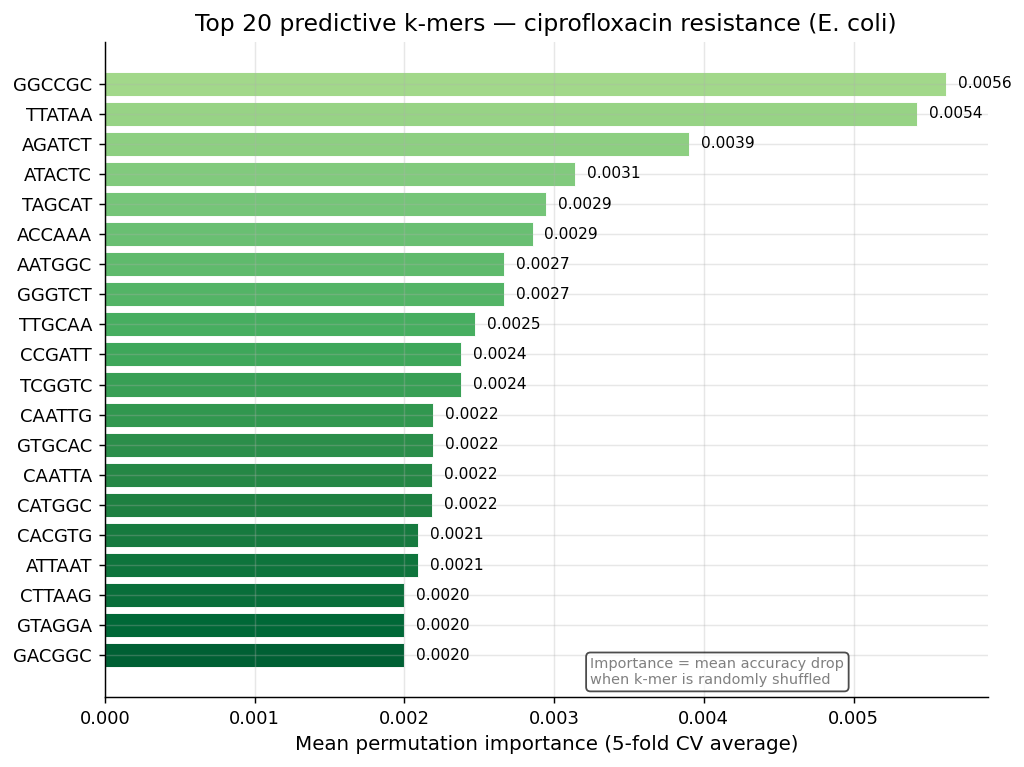

In [17]:
imp_path = os.path.join(DATA_DIR, 'feature_importances.csv')
imp_df   = pd.read_csv(imp_path).head(20)

fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.YlGn(np.linspace(0.4, 0.9, len(imp_df))[::-1])
bars   = ax.barh(imp_df['feature'][::-1],
                 imp_df['importance'][::-1],
                 color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, imp_df['importance'][::-1]):
    ax.text(val + 0.00008, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Mean permutation importance (5-fold CV average)')
ax.set_title('Top 20 predictive k-mers — ciprofloxacin resistance (E. coli)')
ax.text(0.55, 0.02,
        'Importance = mean accuracy drop\nwhen k-mer is randomly shuffled',
        transform=ax.transAxes, fontsize=8, color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'top_features.png'), dpi=150, bbox_inches='tight')
plt.show()

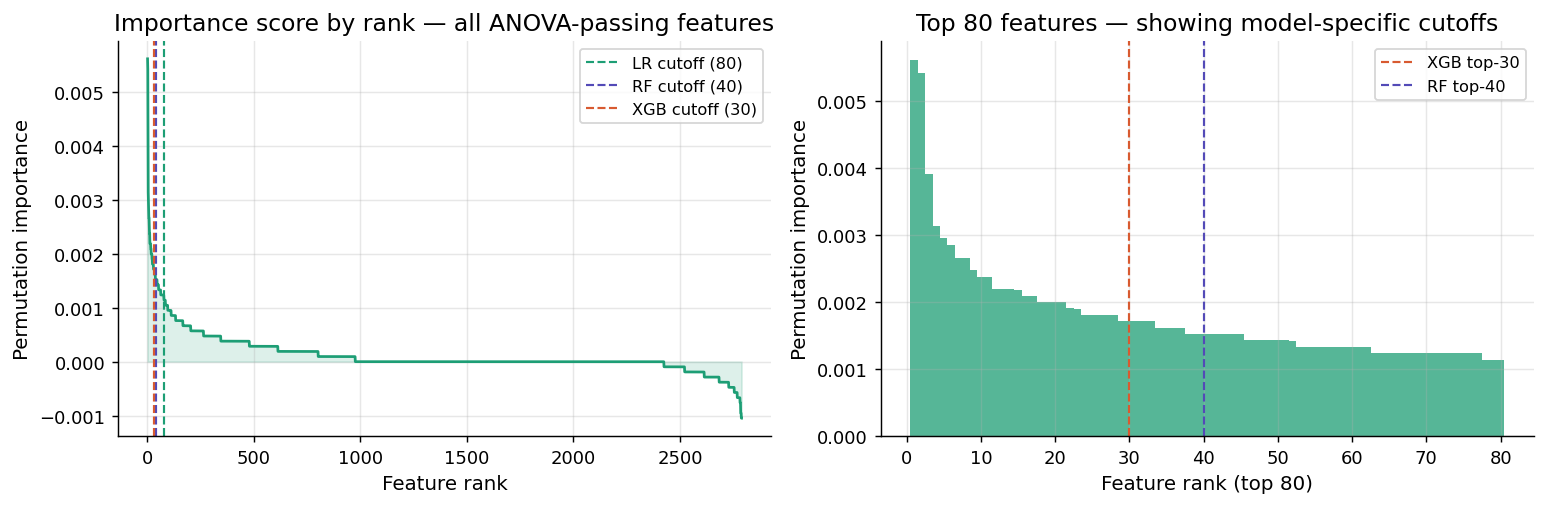

In [18]:
imp_all = pd.read_csv(imp_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full ranked importance curve
ax = axes[0]
ax.plot(range(1, len(imp_all)+1), imp_all['importance'],
        color='#1D9E75', lw=1.5)
ax.fill_between(range(1, len(imp_all)+1), imp_all['importance'],
                alpha=0.15, color='#1D9E75')
ax.axvline(80,  color=COLORS['LR'],  linestyle='--', lw=1.2, label='LR cutoff (80)')
ax.axvline(40,  color=COLORS['RF'],  linestyle='--', lw=1.2, label='RF cutoff (40)')
ax.axvline(30,  color=COLORS['XGB'], linestyle='--', lw=1.2, label='XGB cutoff (30)')
ax.set_xlabel('Feature rank')
ax.set_ylabel('Permutation importance')
ax.set_title('Importance score by rank — all ANOVA-passing features')
ax.legend(fontsize=9)

# Right: top 80 zoomed
ax2 = axes[1]
top80 = imp_all.head(80)
ax2.bar(range(1, 81), top80['importance'], color='#1D9E75', alpha=0.75, width=1)
ax2.axvline(30, color=COLORS['XGB'], linestyle='--', lw=1.2, label='XGB top-30')
ax2.axvline(40, color=COLORS['RF'],  linestyle='--', lw=1.2, label='RF top-40')
ax2.set_xlabel('Feature rank (top 80)')
ax2.set_ylabel('Permutation importance')
ax2.set_title('Top 80 features — showing model-specific cutoffs')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'feature_importance_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

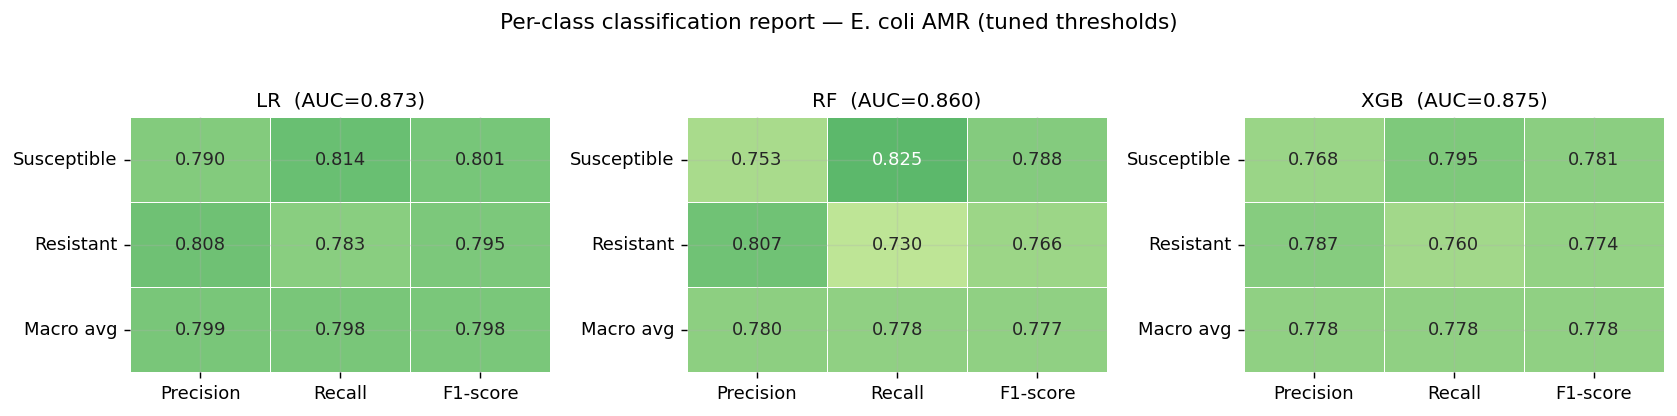

In [24]:
from sklearn.metrics import classification_report
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

for ax, (k, m) in zip(axes, MODELS.items()):
    report = classification_report(m['yte'], m['te_pred'],
                                   target_names=['Susceptible','Resistant'],
                                   output_dict=True)
    df_rep = pd.DataFrame(report).T.loc[
        ['Susceptible','Resistant','macro avg'],
        ['precision','recall','f1-score']
    ].astype(float)

    sns.heatmap(df_rep, annot=True, fmt='.3f', cmap='YlGn',
                vmin=0.6, vmax=1.0, linewidths=0.5,
                cbar=False, ax=ax)

    auc = roc_auc_score(m['yte'], m['te_prob'])
    ax.set_title(f'{k}  (AUC={auc:.3f})', fontsize=11)
    ax.set_ylabel('')

    # ── ADD THESE THREE LINES ──────────────────────────────
    ax.set_yticklabels(['Susceptible', 'Resistant', 'Macro avg'],
                        rotation=0, fontsize=10)
    ax.set_xticklabels(['Precision', 'Recall', 'F1-score'],
                        rotation=0, fontsize=10)
    # ───────────────────────────────────────────────────────

plt.suptitle('Per-class classification report — E. coli AMR (tuned thresholds)',
             fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'classification_report_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

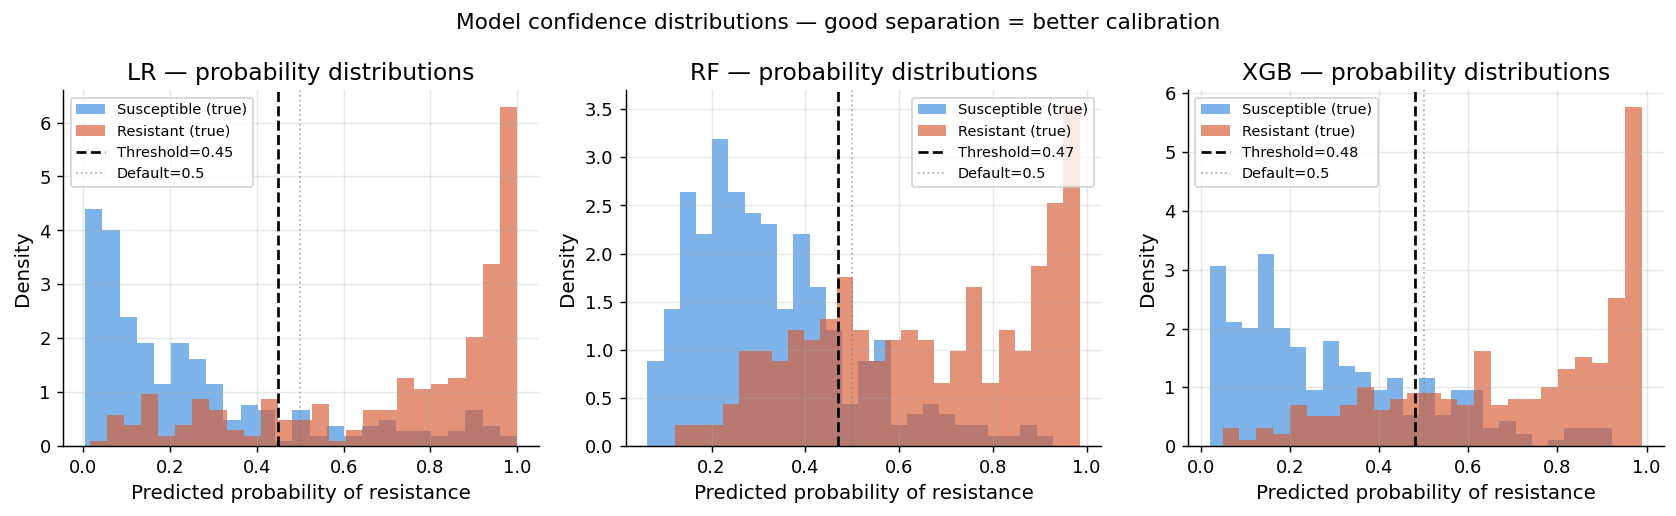

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, (k, m) in zip(axes, MODELS.items()):
    sus_probs = m['te_prob'][m['yte'] == 0]
    res_probs = m['te_prob'][m['yte'] == 1]

    ax.hist(sus_probs, bins=25, alpha=0.65, color='#378ADD',
            label='Susceptible (true)', density=True)
    ax.hist(res_probs, bins=25, alpha=0.65, color='#D85A30',
            label='Resistant (true)', density=True)
    ax.axvline(m['threshold'], color='black', linestyle='--',
               lw=1.5, label=f'Threshold={m["threshold"]}')
    ax.axvline(0.5, color='gray', linestyle=':', lw=1, alpha=0.6, label='Default=0.5')
    ax.set_xlabel('Predicted probability of resistance')
    ax.set_ylabel('Density')
    ax.set_title(f'{k} — probability distributions')
    ax.legend(fontsize=8)

plt.suptitle('Model confidence distributions — good separation = better calibration',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'probability_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [25]:
saved = [
    ('roc_curves.png',                   'ROC curves with operating point'),
    ('pr_curves.png',                    'Precision-Recall curves'),
    ('confusion_matrices.png',           'Confusion matrices (all models)'),
    ('overfitting_diagnostic.png',       'Train vs Test AUC + gap chart'),
    ('metric_comparison.png',            'All metrics side-by-side'),
    ('threshold_impact.png',             'Default vs tuned threshold impact'),
    ('top_features.png',                 'Top 20 k-mer importances'),
    ('feature_importance_distribution.png', 'Full importance rank curve'),
    ('classification_report_heatmap.png','Per-class precision/recall/F1'),
    ('probability_distributions.png',   'Model confidence distributions'),
]

print(f'\n{"="*55}')
print(f'  All figures saved to: {DATA_DIR}')
print(f'{"="*55}')
for fname, desc in saved:
    full = os.path.join(DATA_DIR, fname)
    status = 'OK' if os.path.exists(full) else 'MISSING'
    print(f'  [{status:7s}] {fname:<45s} {desc}')


  All figures saved to: C:\AMR_Prediction_Project\Data\results_ecoli
  [OK     ] roc_curves.png                                ROC curves with operating point
  [OK     ] pr_curves.png                                 Precision-Recall curves
  [OK     ] confusion_matrices.png                        Confusion matrices (all models)
  [OK     ] overfitting_diagnostic.png                    Train vs Test AUC + gap chart
  [OK     ] metric_comparison.png                         All metrics side-by-side
  [OK     ] threshold_impact.png                          Default vs tuned threshold impact
  [OK     ] top_features.png                              Top 20 k-mer importances
  [OK     ] feature_importance_distribution.png           Full importance rank curve
  [OK     ] classification_report_heatmap.png             Per-class precision/recall/F1
  [OK     ] probability_distributions.png                 Model confidence distributions
